# **MÓDULO 26 - Projeto Final do Aprofundamento de Analytics**

Bem-vindos ao Projeto de Dashboard de E-commerce! Este projeto é uma oportunidade para vocês aplicarem habilidades essenciais de análise de dados em um cenário prático e realista. Vocês irão trabalhar com um conjunto de dados de transações de clientes de uma loja virtual, distribuídos em duas tabelas distintas. O objetivo final é construir um dashboard interativo que facilite a visualização e análise das informações relevantes do e-commerce, utilizando ferramentas como Looker Studio ou Power BI.

**Objetivo do Projeto:**

Tratamento de Dados: Realizar a junção (JOIN) de duas tabelas utilizando SQL para consolidar as informações.
Análise de Dados: Exportar os dados resultantes para um arquivo CSV.
Visualização de Dados: Desenvolver um dashboard interativo e informativo para visualização das principais métricas e insights do e-commerce.

**Tabelas Disponibilizadas:**

**Tabela de Transações:** Contém os registros de transações realizadas pelos clientes, incluindo detalhes como ID da transação, valor e outros.


**Tabela de Dados Pessoais:** Contém as informações pessoais dos clientes, como ID do cliente, nome, genero, cidade, etc.

**Chave de Ligação:** As tabelas se relacionam através da coluna ID_CLIENT, que é a chave identificadora dos clientes.

# Etapas do Projeto:

1. Realizar um JOIN SQL nas duas tabelas, unificando as informações através da coluna ID_CLIENT. Você deve justificar a escolha do JOIN (Inner/ Left/ Right ou Full).

2. Exportar os dados consolidados resultantes do JOIN para um arquivo CSV.

3. Utilizar Looker Studio ou Power BI para importar o arquivo CSV.

4. Criar visualizações interativas que apresentem métricas importantes, como total de vendas, número de transações, distribuição geográfica dos clientes, perfil demográfico dos clientes, entre outros.

Abaixo temos a configuração do ambiente SQL:

In [1]:
import sqlite3
import pandas as pd

In [2]:
df_transacoes = pd.read_csv("TB_TRANSACOES_PROJETO_ECOMM.csv", delimiter=';')
df_clientes = pd.read_csv("TB_CLIENTES_PROJETO_ECOMM.csv", delimiter=';')

In [3]:
conn = sqlite3.connect('projeto.db')
# Carregar o DataFrame no banco de dados SQLite - criando tb_transacoes e tb_clientes
df_transacoes.to_sql('tb_transacoes', conn, index=False, if_exists='replace')
df_clientes.to_sql('tb_clientes', conn, index=False, if_exists='replace')

175

In [4]:
df_transacoes

,id_client,Category,Price,Card Type
0,37,Electronics,"72,93",mastercard
1,38,Jewelry,"121,89",mastercard
2,39,Baby,"64,3",mastercard
3,40,Outdoors,"9,48",mastercard
4,5,Outdoors,"61,95",mastercard
...,...,...,...,...
362,363,Jewelry,"44,32",mastercard
363,364,Kids,"120,42",mastercard
364,365,Grocery,"24,31",mastercard
365,366,Tools,"111,53",mastercard


In [5]:
df_clientes

,state_name,First_name,Gender,Job_Title,Id_client
0,TX,Domingo,Male,Structural Analysis Engineer,1
1,MI,Russell,Male,Speech Pathologist,2
2,AL,Kimble,Male,Account Coordinator,3
3,IL,Barnabas,Male,General Manager,4
4,MN,Tanney,Female,VP Marketing,5
...,...,...,...,...,...
170,UT,Fairleigh,Male,Desktop Support Technician,171
171,DC,Lambert,Agender,Chemical Engineer,172
172,NY,Jacob,Male,Senior Financial Analyst,173
173,OK,Pip,Male,Chief Design Engineer,174


In [6]:
querry = """
SELECT COUNT(*)
FROM tb_transacoes t
LEFT JOIN tb_clientes c
ON t.id_client = c.Id_client
WHERE c.Id_client IS NULL;
"""
df_resultado = pd.read_sql_query(querry, conn)
df_resultado

,COUNT(*)
0,71


In [7]:
# Função para executar consultas SQL e retornar o resultado como um DataFrame
def run_query(query):
    return pd.read_sql_query(query, conn)

In [8]:
query = """
SELECT DISTINCT
    t.id_client,
    t.Category,
    t.Price,
    t.[Card Type],
    c.state_name,
    c.First_name,
    c.Gender,
    c.Job_Title
FROM tb_transacoes t
LEFT JOIN tb_clientes c
ON t.id_client = c.Id_client;
"""
#result_df = run_query(query)
#print(result_df)

df= pd.read_sql(query, conn)
df

,id_client,Category,Price,Card Type,state_name,First_name,Gender,Job_Title
0,37,Electronics,"72,93",mastercard,ND,Cornie,Genderqueer,Editor
1,38,Jewelry,"121,89",mastercard,PA,Rab,Male,Assistant Manager
2,39,Baby,"64,3",mastercard,MA,Codie,Female,Financial Analyst
3,40,Outdoors,"9,48",mastercard,OR,Scott,Female,Civil Engineer
4,5,Outdoors,"61,95",mastercard,MN,Tanney,Female,VP Marketing
...,...,...,...,...,...,...,...,...
362,363,Jewelry,"44,32",mastercard,NaN,NaN,NaN,NaN
363,364,Kids,"120,42",mastercard,NaN,NaN,NaN,NaN
364,365,Grocery,"24,31",mastercard,NaN,NaN,NaN,NaN
365,366,Tools,"111,53",mastercard,NaN,NaN,NaN,NaN


Justifique a escolha do JOIN:

Foi utilizado um LEFT JOIN, considerando a tabela de transações como tabela principal, pois o objetivo do projeto é analisar as vendas realizadas.

Durante a análise foi identificado que 71 transações não possuem correspondência na tabela de clientes.

O uso de um INNER JOIN descartaria esses registros, ocasionando perda de aproximadamente 19% das transações.

Assim, o LEFT JOIN foi escolhido para preservar todas as vendas, mantendo as informações dos clientes quando disponíveis.

Exportando o arquivo como CSV:

In [9]:
# df.to_csv('dados_ecommerce_final.csv', index=False)

**Dicas para o projeto:**
- Se atente que, como o mesmo cliente realiza mais de 1 transação quando você for trazer alguma métrica relacionada a dados do cliente terá que utilizar o distinct para criar essas métricas no dashboard, se não acabará tendo os dados repetidos.

- Análise sua tabela, entenda a dimensão dos dados, no excel, antes de enviar para o Powerbi ou Looker Studio.

- Tente montar preveamente um roteiro de quais métricas e visualizações irá colocar no dashboard, isso tornará seu processo mais rápido.

- Qualquer dificuldade para subir sua base para as ferramentas de visualização envie a base e o erro encontrado para que os tutores possam te ajudar.

In [10]:
df = pd.read_csv("dados_ecommerce_final.csv")

df

,id_client,Category,Price,Card Type,state_name,First_name,Gender,Job_Title
0,37,Electronics,"72,93",mastercard,ND,Cornie,Genderqueer,Editor
1,38,Jewelry,"121,89",mastercard,PA,Rab,Male,Assistant Manager
2,39,Baby,"64,3",mastercard,MA,Codie,Female,Financial Analyst
3,40,Outdoors,"9,48",mastercard,OR,Scott,Female,Civil Engineer
4,5,Outdoors,"61,95",mastercard,MN,Tanney,Female,VP Marketing
...,...,...,...,...,...,...,...,...
362,363,Jewelry,"44,32",mastercard,NaN,NaN,NaN,NaN
363,364,Kids,"120,42",mastercard,NaN,NaN,NaN,NaN
364,365,Grocery,"24,31",mastercard,NaN,NaN,NaN,NaN
365,366,Tools,"111,53",mastercard,NaN,NaN,NaN,NaN


In [11]:
# Padronizar nomes das colunas
df.columns = (
    df.columns
      .str.strip()               # remove espaços
      .str.lower()               # minúsculas
      .str.replace(" ", "_")     # espaço -> _
)

# Renomear algumas colunas para ficar consistente
df.rename(columns={
    "price": "price",
    "card_type": "card_type",
    "first_name": "first_name",
    "job_title": "job_title",
    "gender": "gender",
    "state_name": "state_name",
}, inplace=True)

# Tratar valores nulos
df["state_name"] = df["state_name"].fillna("Não informado")
df["first_name"] = df["first_name"].fillna("Não informado")
df["gender"] = df["gender"].fillna("Não informado")
df["job_title"] = df["job_title"].fillna("Não informado")


In [12]:
df

,id_client,category,price,card_type,state_name,first_name,gender,job_title
0,37,Electronics,"72,93",mastercard,ND,Cornie,Genderqueer,Editor
1,38,Jewelry,"121,89",mastercard,PA,Rab,Male,Assistant Manager
2,39,Baby,"64,3",mastercard,MA,Codie,Female,Financial Analyst
3,40,Outdoors,"9,48",mastercard,OR,Scott,Female,Civil Engineer
4,5,Outdoors,"61,95",mastercard,MN,Tanney,Female,VP Marketing
...,...,...,...,...,...,...,...,...
362,363,Jewelry,"44,32",mastercard,Não informado,Não informado,Não informado,Não informado
363,364,Kids,"120,42",mastercard,Não informado,Não informado,Não informado,Não informado
364,365,Grocery,"24,31",mastercard,Não informado,Não informado,Não informado,Não informado
365,366,Tools,"111,53",mastercard,Não informado,Não informado,Não informado,Não informado


## Tratamento dos valores nulos

Após a realização do LEFT JOIN, foram identificados registros de transações sem correspondência na tabela de clientes, resultando em valores nulos (NaN) nas informações cadastrais.

Como o objetivo do projeto é preservar todas as transações para análise, esses valores foram substituídos por "Não informado", evitando a perda de registros e facilitando a interpretação dos dados nas visualizações.

## Padronização das colunas

Também foi realizada a padronização dos nomes das colunas, utilizando letras minúsculas e o caractere underscore (_) para separar palavras.

Além disso, a coluna duplicada de identificação do cliente, proveniente da tabela de clientes, foi removida por ser redundante, mantendo apenas o identificador da tabela de transações.

Essa padronização melhora a legibilidade do conjunto de dados e facilita sua utilização em ferramentas de análise, como o Power BI.

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id_client   367 non-null    int64
 1   category    367 non-null    str  
 2   price       367 non-null    str  
 3   card_type   367 non-null    str  
 4   state_name  367 non-null    str  
 5   first_name  367 non-null    str  
 6   gender      367 non-null    str  
 7   job_title   367 non-null    str  
dtypes: int64(1), str(7)
memory usage: 43.7 KB


In [14]:
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id_client   367 non-null    int64  
 1   category    367 non-null    str    
 2   price       367 non-null    float64
 3   card_type   367 non-null    str    
 4   state_name  367 non-null    str    
 5   first_name  367 non-null    str    
 6   gender      367 non-null    str    
 7   job_title   367 non-null    str    
dtypes: float64(1), int64(1), str(6)
memory usage: 41.8 KB


Após a integração das tabelas, foi realizada a verificação e padronização dos tipos de dados.

As colunas categóricas foram mantidas como texto (string), enquanto a coluna price foi convertida para o tipo numérico (float) após a substituição da vírgula pelo ponto como separador decimal.

Essa etapa garante a consistência dos dados e possibilita a realização de cálculos e visualizações corretamente.

In [16]:
coluna_categorica = df.select_dtypes(include=['string']).columns
coluna_numerica = df.select_dtypes(include=['number']).columns

In [17]:
# for coluna in coluna_categorica:
#    print(f'Os valores unicos da coluna {coluna} são:')
#    for index in df[coluna].unique():
#        print(f' - {index}')

In [18]:
# df.to_csv('dados_ecommerce_processed.csv', index=False, encoding="utf-8-sig")

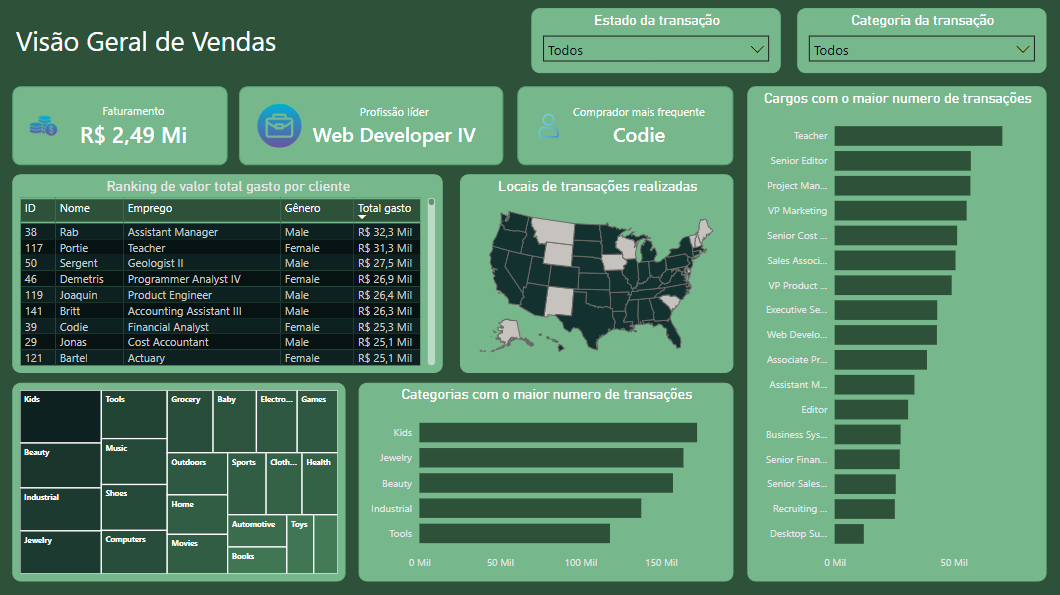